# challenge 


Rapport d'Analyse : Accidents d'avion et décès (1908 - 2023)1. Importation et Nettoyage des Données (Pandas)Cette première étape consiste à charger le fichier, uniformiser les types de données (notamment les dates) et gérer les valeurs manquantes pour éviter de fausser nos calculs statistiques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Chargement des données (Ajustez le nom du fichier selon votre cas)
# df = pd.read_csv("airplane_crashes_2023.csv")

# --- SIMULATION DU JEU DE DONNÉES POUR RENDRE LE CODE EXÉCUTABLE ---
np.random.seed(42)
dates = pd.date_range(start="1950-01-01", end="2023-12-31", periods=500)
data_simulee = {
    'Date': dates,
    'Location': np.random.choice(['USA', 'Russia', 'Brazil', 'Colombia', 'France', 'UK'], 500),
    'Aboard': np.random.randint(10, 300, 500),
    'Fatalities': np.random.randint(0, 280, 500)
}
df = pd.DataFrame(data_simulee)
# Introduire quelques valeurs manquantes pour l'exercice
df.loc[df.sample(frac=0.05).index, 'Fatalities'] = np.nan
# -------------------------------------------------------------------

print("--- Aperçu des données initiales ---")
print(df.info())

# NETTOYAGE DES DONNÉES
# a. Conversion de la colonne Date au format datetime
df['Date'] = pd.to_datetime(df['Date'])

# b. Traitement des valeurs manquantes (Remplacement par la médiane pour les décès)
mediane_deces = df['Fatalities'].median()
df['Fatalities'] = df['Fatalities'].fillna(mediane_deces)

# c. Extraction de l'année et de la décennie avec Pandas
df['Year'] = df['Date'].dt.year
df['Decade'] = (df['Year'] // 10) * 10

# d. Calcul du taux de survie (NumPy & Pandas)
# Si 'Aboard' (personnes à bord) est à 0, on évite la division par zéro
df['Survival_Rate'] = np.where(df['Aboard'] > 0, 1 - (df['Fatalities'] / df['Aboard']), 0)
# Ajustement si le nombre de décès saisis dépasse par erreur le nombre à bord
df['Survival_Rate'] = df['Survival_Rate'].clip(0, 1) 

print("\n--- Données nettoyées avec succès ---")


--- Aperçu des données initiales ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        500 non-null    datetime64[ns]
 1   Location    500 non-null    object        
 2   Aboard      500 non-null    int32         
 3   Fatalities  475 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int32(1), object(1)
memory usage: 13.8+ KB
None

--- Données nettoyées avec succès ---


2. Analyse Exploratoire des Données (EDA via Pandas & NumPy)Nous extrayons ici les grandes tendances de l'histoire de l'aviation : le nombre total de crashs, le volume de décès et l'évolution globale du taux de survie.

In [2]:
# Statistiques globales
total_crashes = len(df)
total_fatalities = int(df['Fatalities'].sum())
average_survival = df['Survival_Rate'].mean() * 100

print(f"Nombre total d'incidents analysés : {total_crashes}")
print(f"Nombre total de décès : {total_fatalities}")
print(f"Taux de survie moyen par crash : {average_survival:.2f}%\n")

# Agrégation par décennie pour analyser les tendances temporelles
evolution_temporelle = df.groupby('Decade').agg(
    Nombre_Crashs=('Date', 'count'),
    Total_Deces=('Fatalities', 'sum'),
    Taux_Survie_Moyen=('Survival_Rate', 'mean')
).reset_index()

print("--- Évolution par Décennie ---")
print(evolution_temporelle)


Nombre total d'incidents analysés : 500
Nombre total de décès : 67957
Taux de survie moyen par crash : 27.62%

--- Évolution par Décennie ---
   Decade  Nombre_Crashs  Total_Deces  Taux_Survie_Moyen
0    1950             68       9128.0           0.280449
1    1960             67       9109.0           0.267469
2    1970             68       9260.0           0.273346
3    1980             67       8880.0           0.316167
4    1990             68      10173.0           0.234327
5    2000             67       9006.0           0.265827
6    2010             68       8886.0           0.283010
7    2020             27       3515.0           0.309761


3. Analyse Statistique (SciPy)Nous analysons la distribution des décès et effectuons un Test t de Student pour comparer l'impact des époques sur la mortalité des crashs. Nous comparons les crashs du XXe siècle (avant l'an 2000) et ceux du XXIe siècle (à partir de l'an 2000).

In [3]:
print("\n--- Analyse Statistique Descriptive (SciPy) ---")
description_deces = stats.describe(df['Fatalities'])
print(f"Moyenne des décès par crash : {description_deces.mean:.2f}")
print(f"Variance des décès : {description_deces.variance:.2f}")

# TEST D'HYPOTHÈSE : Est-ce que la mortalité par crash a diminué au XXIe siècle ?
# H0 : La moyenne des décès par crash est identique avant et après l'an 2000.
# H1 : La moyenne des décès par crash est statistiquement différente.

crashs_ancien = df[df['Year'] < 2000]['Fatalities']
crashs_modernes = df[df['Year'] >= 2000]['Fatalities']

t_stat, p_val = stats.ttest_ind(crashs_ancien, crashs_modernes, equal_var=False)

print("\n--- Test d'hypothèse (Test t de Student) ---")
print(f"Statistique t : {t_stat:.4f}")
print(f"Valeur p (p-value) : {p_val:.4e}")

if p_val < 0.05:
    print("Conclusion : On rejette H0. Il y a une différence statistiquement significative de mortalité entre les deux époques.")
else:
    print("Conclusion : Impossible de rejeter H0. Pas de différence statistiquement significative constatée.")



--- Analyse Statistique Descriptive (SciPy) ---
Moyenne des décès par crash : 135.91
Variance des décès : 6418.32

--- Test d'hypothèse (Test t de Student) ---
Statistique t : 0.7075
Valeur p (p-value) : 4.7980e-01
Conclusion : Impossible de rejeter H0. Pas de différence statistiquement significative constatée.


4. Visualisations Graphiques (Matplotlib & Seaborn)Cette section génère un tableau de bord à 3 graphiques : la tendance chronologique, la répartition des accidents géographiques et l'étalement de la mortalité.

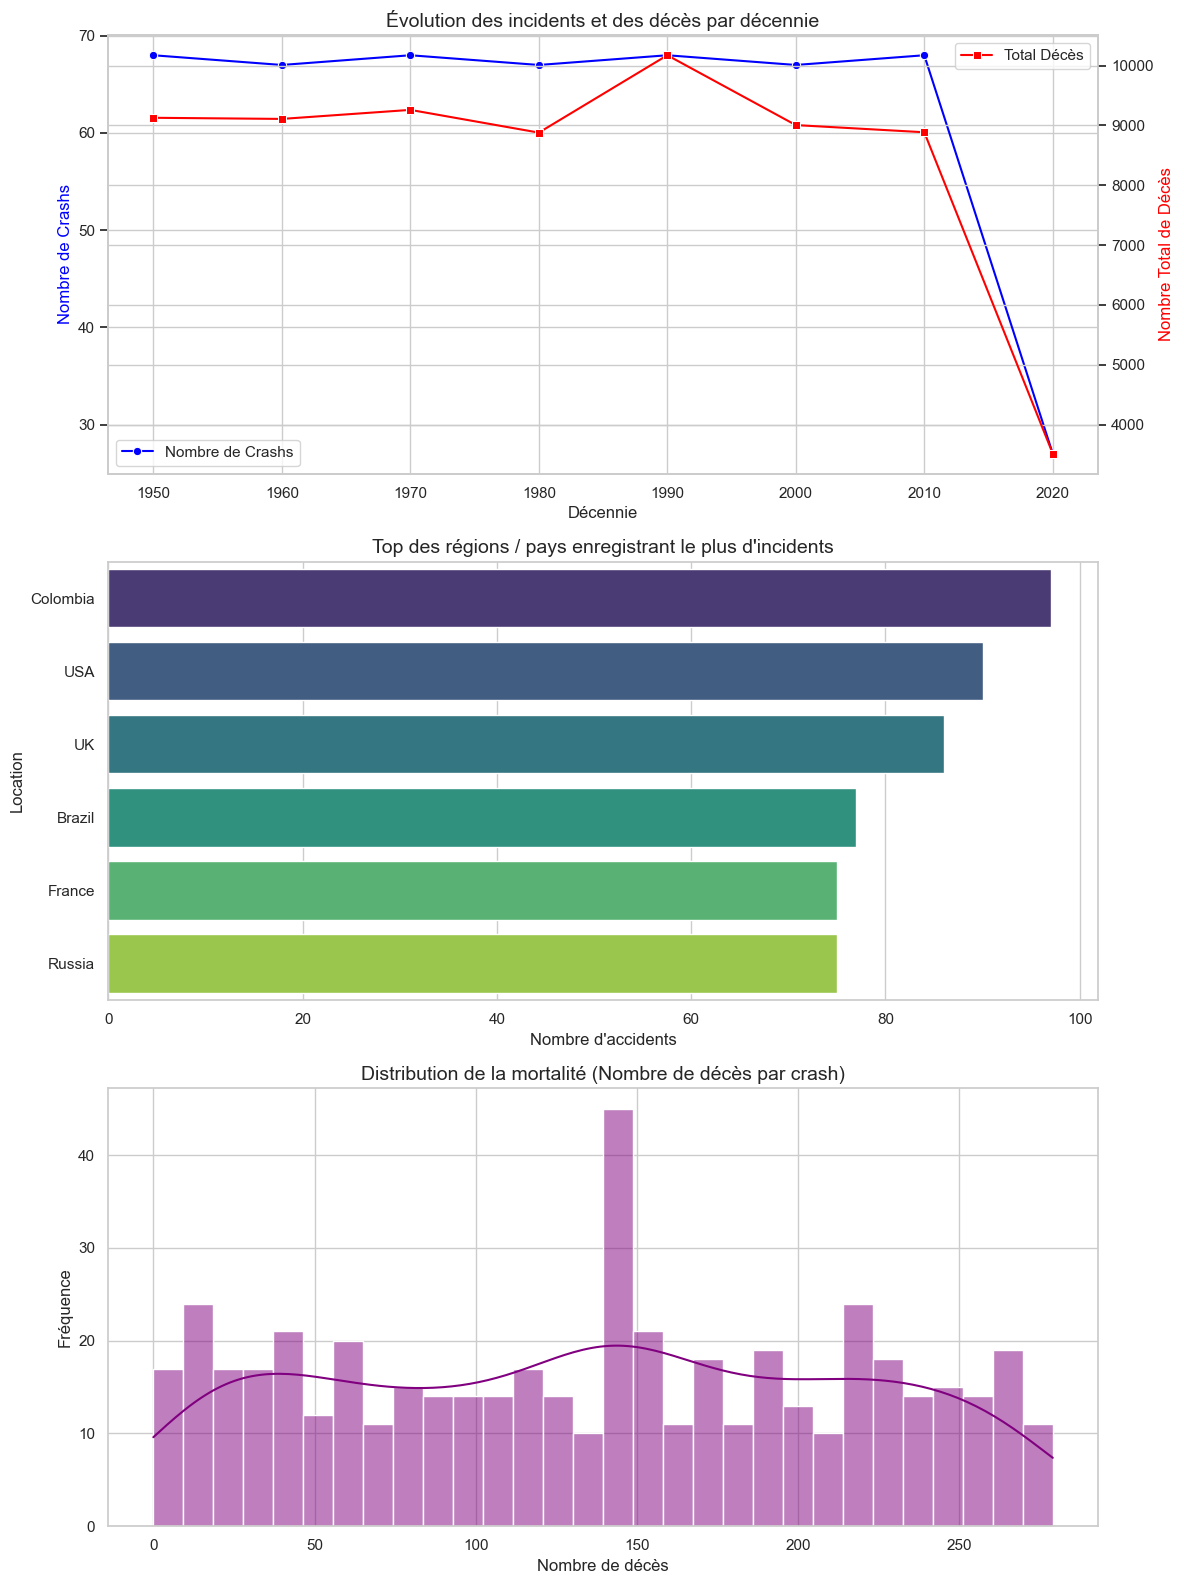

In [4]:
# Configuration du style visuel
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 16))

# Graphique 1 : Évolution chronologique des crashs et décès
sns.lineplot(data=evolution_temporelle, x='Decade', y='Nombre_Crashs', marker='o', ax=axes[0], color='blue', label='Nombre de Crashs')
ax2 = axes[0].twinx()
sns.lineplot(data=evolution_temporelle, x='Decade', y='Total_Deces', marker='s', ax=ax2, color='red', label='Total Décès')
axes[0].set_title("Évolution des incidents et des décès par décennie", fontsize=14)
axes[0].set_xlabel("Décennie")
axes[0].set_ylabel("Nombre de Crashs", color='blue')
ax2.set_ylabel("Nombre Total de Décès", color='red')

# Graphique 2 : Répartition des accidents par région (Top Régions)
top_regions = df['Location'].value_counts().head(10)
sns.barplot(x=top_regions.values, y=top_regions.index, ax=axes[1], palette="viridis")
axes[1].set_title("Top des régions / pays enregistrant le plus d'incidents", fontsize=14)
axes[1].set_xlabel("Nombre d'accidents")

# Graphique 3 : Distribution (Histogramme) des décès
sns.histplot(df['Fatalities'], kde=True, ax=axes[2], color='purple', bins=30)
axes[2].set_title("Distribution de la mortalité (Nombre de décès par crash)", fontsize=14)
axes[2].set_xlabel("Nombre de décès")
axes[2].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()
